In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from pathlib import Path

X_train = np.load('../data/X_cv.npy')
y_train = np.load('../data/y_cv.npy')
X_holdout = np.load('../data/X_holdout.npy')
y_holdout = np.load('../data/y_holdout.npy')
feature_names = joblib.load('../models/feature_names.pkl')
best_model = joblib.load('../models/best_lgbm.pkl')

print(f"X_train:   {X_train.shape}")
print(f"X_holdout: {X_holdout.shape}")
print(f"Features:  {len(feature_names)}")

X_train:   (16213, 190)
X_holdout: (2432, 190)
Features:  190


In [5]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_holdout)

print(f"shap_values type:  {type(shap_values)}")
print(f"shap_values shape: {np.array(shap_values).shape}")

shap_values type:  <class 'numpy.ndarray'>
shap_values shape: (2432, 190)


d:\projects\CoughDetector\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


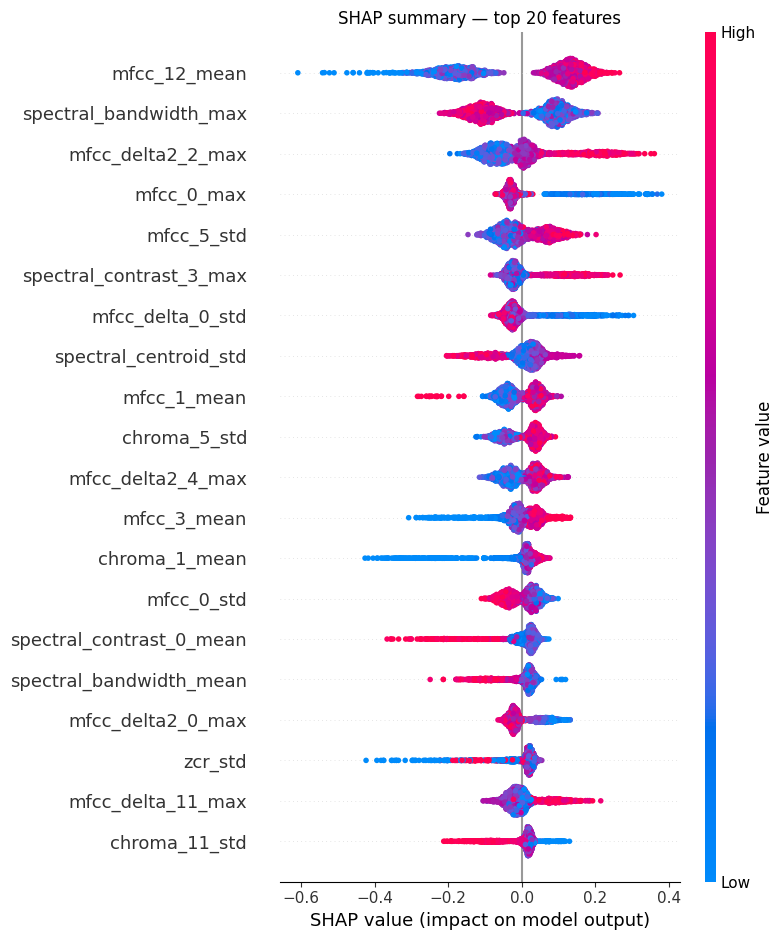

In [6]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_holdout,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP summary — top 20 features")
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

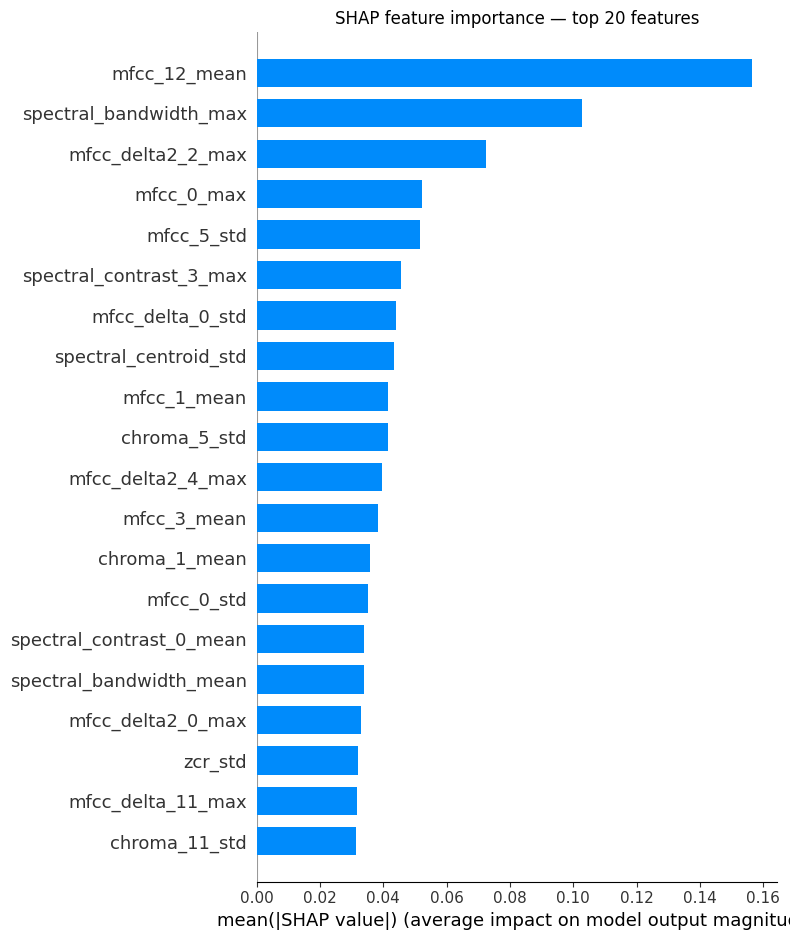

In [7]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_holdout,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP feature importance — top 20 features")
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
best_params = {
    'n_estimators': 188,
    'num_leaves': 38,
    'learning_rate': 0.02384683056822627,
    'min_child_samples': 29,
    'subsample': 0.8157744551645475,
    'colsample_bytree': 0.6173849978053825
}

In [9]:
import lightgbm as lgb
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Split X_train into 85% for ablation (same split as modelling)
from sklearn.model_selection import train_test_split
X_tr, _, y_tr, _ = train_test_split(
    X_train, y_train, test_size=0.15,
    random_state=42, stratify=y_train
)

# Define feature groups by index ranges
feature_groups = {
    'all_features':   list(range(190)),
    'mfcc_only':      list(range(0, 117)),
    'spectral_only':  list(range(117, 147)),
    'temporal_only':  list(range(147, 153)),
    'chroma_only':    list(range(153, 189)),
    'no_mfcc':        list(range(117, 190)),
}

ablation_results = {}

for group_name, indices in feature_groups.items():
    model = lgb.LGBMClassifier(
        **best_params,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    scores = cross_validate(
        model, X_tr[:, indices], y_tr,
        cv=cv,
        scoring={'auroc': make_scorer(roc_auc_score,
                 response_method='predict_proba')},
        return_train_score=False
    )
    ablation_results[group_name] = {
        'auroc_mean': scores['test_auroc'].mean(),
        'auroc_std':  scores['test_auroc'].std(),
        'n_features': len(indices)
    }
    print(f"{group_name:20s} | features: {len(indices):3d} | "
          f"AUROC: {scores['test_auroc'].mean():.4f} ± {scores['test_auroc'].std():.4f}")

all_features         | features: 190 | AUROC: 0.6187 ± 0.0146
mfcc_only            | features: 117 | AUROC: 0.6015 ± 0.0126
spectral_only        | features:  30 | AUROC: 0.5907 ± 0.0224
temporal_only        | features:   6 | AUROC: 0.5424 ± 0.0154
chroma_only          | features:  36 | AUROC: 0.5502 ± 0.0053
no_mfcc              | features:  73 | AUROC: 0.5996 ± 0.0184


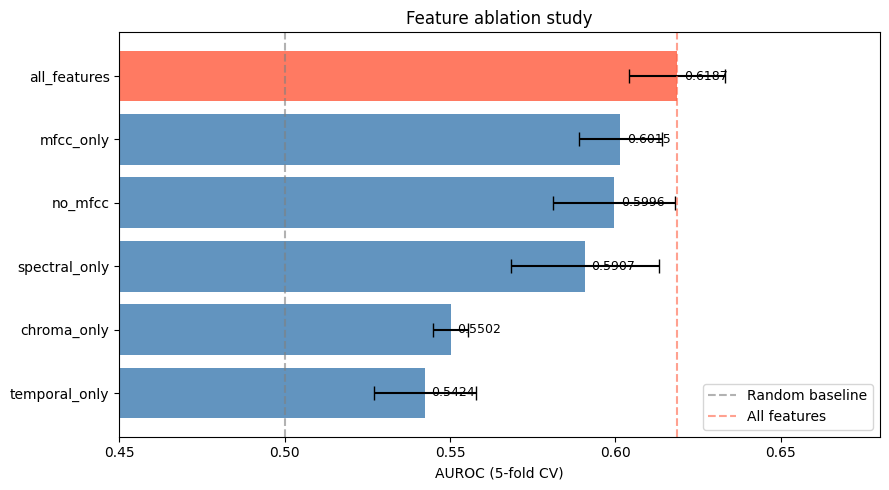

In [10]:
ablation_df = pd.DataFrame(ablation_results).T.sort_values('auroc_mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    ablation_df.index,
    ablation_df['auroc_mean'],
    xerr=ablation_df['auroc_std'],
    color=['tomato' if i == 'all_features' else 'steelblue'
           for i in ablation_df.index],
    alpha=0.85, capsize=5
)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Random baseline')
ax.axvline(x=ablation_results['all_features']['auroc_mean'],
           color='tomato', linestyle='--', alpha=0.6, label='All features')
ax.set_xlabel('AUROC (5-fold CV)')
ax.set_title('Feature ablation study')
ax.set_xlim(0.45, 0.68)
ax.legend()

for bar, (_, row) in zip(bars, ablation_df.iterrows()):
    ax.text(row['auroc_mean'] + 0.002, bar.get_y() + bar.get_height()/2,
            f"{row['auroc_mean']:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
summary = {
    'model': 'LightGBM (Optuna tuned)',
    'cv_auroc_mean': 0.6187,
    'cv_auroc_std': 0.0146,
    'holdout_auroc': 0.6179,
    'holdout_macro_f1': 0.5380,
    'training_samples': 13781,
    'holdout_samples': 2432,
    'n_features': 190,
    'top_feature': 'mfcc_12_mean',
}

pd.DataFrame([summary]).to_csv('../outputs/final_results.csv', index=False)
print("Results saved to outputs/final_results.csv")
print("\nProject summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

Results saved to outputs/final_results.csv

Project summary:
  model: LightGBM (Optuna tuned)
  cv_auroc_mean: 0.6187
  cv_auroc_std: 0.0146
  holdout_auroc: 0.6179
  holdout_macro_f1: 0.538
  training_samples: 13781
  holdout_samples: 2432
  n_features: 190
  top_feature: mfcc_12_mean
